In [1]:
"""
CANONICAL NOTEBOOK: use this masked workflow for ERA5-Land comparisons.
COMPARE GEOS-LDAS SURFACE SOIL MOISTURE (SFMC) TO ERA5-LAND SWVL1
==================================================================
This notebook:
 1. Reads the GEOS-LDAS tilecoord binary and model output.
 2. Builds the exact M36 grid geometry from tile bounds.
 3. Regrids ERA5-Land monthly soil moisture to that grid using xESMF (conservative).
 4. Aggregates model tile data to the same grid (area weighted, land only).
 5. Computes anomaly correlation & ubRMSE between model and ERA5-Land.
"""

import os
import numpy as np
import xarray as xr
import pandas as pd
import struct
import matplotlib.pyplot as plt
import xesmf as xe
import datetime as dt

# === File paths (edit for your system) ===
ftc = '/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/land_sweeper/LS_OLv8_M36/output/SMAP_EASEv2_M36_GLOBAL/rc_out/LS_OLv8_M36.ldas_tilecoord.bin'
# era_nc = '/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper/Evaluation/era_land_sm_2017_monhtly_test.nc'
era_nc = '/Users/amfox/Desktop/geosldas-analysis/ERA5L_monthly_merged_rebuilt.nc'
if not os.path.exists(era_nc):
    raise FileNotFoundError(f'Expected rebuilt ERA5-Land file not found: {era_nc}')
model_nc = "/Users/amfox/Desktop/GEOSldas_diagnostics/test_data/M21C_land_sweeper_v2/OLv8_land_variables_2000_2024_compressed.nc"


In [2]:
# Output filename for summary metrics (set per run)
# Example: 'ERA5L_vs_DAv8_M36_masked_summary.nc' or 'ERA5L_vs_OLv8_M36_masked_summary.nc'
out_nc = 'ERA5L_vs_OLv8_M36_masked_summary.nc'


In [3]:
# --- SOURCE: 1° global grid (centers + bounds) ---
lon_b_src = np.linspace(0.0, 360.0, 361)          # 361 edges
lat_b_src = np.linspace(-90.0, 90.0, 181)         # 181 edges
lon_src   = 0.5*(lon_b_src[:-1] + lon_b_src[1:])  # 360 centers
lat_src   = 0.5*(lat_b_src[:-1] + lat_b_src[1:])  # 180 centers

src = xr.Dataset(
    {
        "lon":    (("lon",), lon_src),
        "lat":    (("lat",), lat_src),
        "lon_b":  (("lon_b",), lon_b_src),
        "lat_b":  (("lat_b",), lat_b_src),
    }
)
src["lon"].attrs.update(standard_name="longitude", units="degrees_east", bounds="lon_b")
src["lat"].attrs.update(standard_name="latitude",  units="degrees_north", bounds="lat_b")
src["lon_b"].attrs.update(standard_name="longitude", units="degrees_east")
src["lat_b"].attrs.update(standard_name="latitude",  units="degrees_north")

# --- TARGET: 6° global grid ---
lon_b_tgt = np.linspace(0.0, 360.0, 61)           # 61 edges
lat_b_tgt = np.linspace(-90.0, 90.0, 31)          # 31 edges
lon_tgt   = 0.5*(lon_b_tgt[:-1] + lon_b_tgt[1:])  # 60 centers
lat_tgt   = 0.5*(lat_b_tgt[:-1] + lat_b_tgt[1:])  # 30 centers

tgt = xr.Dataset(
    {
        "lon":    (("lon",), lon_tgt),
        "lat":    (("lat",), lat_tgt),
        "lon_b":  (("lon_b",), lon_b_tgt),
        "lat_b":  (("lat_b",), lat_b_tgt),
    }
)
tgt["lon"].attrs.update(standard_name="longitude", units="degrees_east", bounds="lon_b")
tgt["lat"].attrs.update(standard_name="latitude",  units="degrees_north", bounds="lat_b")
tgt["lon_b"].attrs.update(standard_name="longitude", units="degrees_east")
tgt["lat_b"].attrs.update(standard_name="latitude",  units="degrees_north")

# --- Build regridder (conservative works because bounds are present) ---
r = xe.Regridder(src, tgt, method="conservative", periodic=True, reuse_weights=False)
print(r)  # should print weights file info


xESMF Regridder 
Regridding algorithm:       conservative 
Weight filename:            conservative_180x360_30x60.nc 
Reuse pre-computed weights? False 
Input grid shape:           (180, 360) 
Output grid shape:          (30, 60) 
Periodic in longitude?      False


In [4]:
def read_tilecoord(fname):
    """Read GEOS-LDAS tilecoord Fortran binary (little-endian)."""
    int_precision = 'i'
    float_precision = 'f'
    machfmt = '<'
    tile_coord = {}
    with open(fname, 'rb') as ifp:
        _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
        tile_coord['N_tile'] = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
        _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
        Nt = tile_coord['N_tile']
        fields = ['tile_id','typ','pfaf','com_lon','com_lat','min_lon','max_lon',
                  'min_lat','max_lat','i_indg','j_indg','frac_cell','frac_pfaf',
                  'area','elev']
        for field in fields:
            _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
            dtype = int_precision if field in ['tile_id','typ','pfaf','i_indg','j_indg'] else float_precision
            arr = np.frombuffer(ifp.read(Nt*4), dtype=f'{machfmt}{dtype}')
            arr = arr.astype(np.float64 if dtype=='f' else np.int32)
            tile_coord[field] = arr
            _ = struct.unpack(f'{machfmt}i', ifp.read(4))[0]
    return tile_coord

def build_m36_grid_cf(tc):
    """Build exact M36 grid with centers and bounds (CF-compliant) from tilecoord."""
    i_indg = tc['i_indg'].astype(int)
    j_indg = tc['j_indg'].astype(int)
    min_lon, max_lon = tc['min_lon'], tc['max_lon']
    min_lat, max_lat = tc['min_lat'], tc['max_lat']
    nx = int(i_indg.max()) + 1
    ny = int(j_indg.max()) + 1

    lon_b = np.full((ny+1, nx+1), np.nan)
    lat_b = np.full((ny+1, nx+1), np.nan)
    for lon0, lon1, lat0, lat1, i, j in zip(min_lon, max_lon, min_lat, max_lat, i_indg, j_indg):
        lon_b[j, i]     = lon0; lon_b[j, i+1] = lon1
        lon_b[j+1, i]   = lon0; lon_b[j+1, i+1] = lon1
        lat_b[j, i]     = lat0; lat_b[j+1, i]   = lat1
        lat_b[j, i+1]   = lat0; lat_b[j+1, i+1] = lat1

    lon_c = 0.5*(lon_b[:-1,:-1] + lon_b[1:,1:])
    lat_c = 0.5*(lat_b[:-1,:-1] + lat_b[1:,1:])

    m36 = xr.Dataset(
        {"lon": (("y","x"), lon_c),
         "lat": (("y","x"), lat_c),
         "lon_b": (("y_b","x_b"), lon_b),
         "lat_b": (("y_b","x_b"), lat_b)}
    )
    m36["lon"].attrs.update(standard_name="longitude", units="degrees_east", bounds="lon_b")
    m36["lat"].attrs.update(standard_name="latitude",  units="degrees_north", bounds="lat_b")
    m36["lon_b"].attrs.update(standard_name="longitude", units="degrees_east")
    m36["lat_b"].attrs.update(standard_name="latitude",  units="degrees_north")
    return m36

def tiles_to_m36_grid(tile_values, tc, m36_grid, land_only=True):
    """Aggregate tile (T,Ntile) to (T, y, x) using frac_cell weights."""
    i_indg = tc['i_indg'].astype(int)
    j_indg = tc['j_indg'].astype(int)
    frac   = tc['frac_cell'].astype(np.float32)
    nx = int(i_indg.max()) + 1
    ny = int(j_indg.max()) + 1

    if tile_values.ndim == 1:
        tile_values = tile_values[np.newaxis,:]
    T = tile_values.shape[0]

    grid_wt  = np.zeros((ny, nx), dtype=np.float32)
    np.add.at(grid_wt, (j_indg, i_indg), frac)
    land_mask = grid_wt > 0
    den = np.where(land_mask, grid_wt, 1.0).astype(np.float32)

    out = np.empty((T, ny, nx), dtype=np.float16)
    acc = np.zeros((ny, nx), dtype=np.float32)

    for t in range(T):
        acc.fill(0.0)
        vals_t = np.nan_to_num(tile_values[t], nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
        np.add.at(acc, (j_indg, i_indg), vals_t * frac)
        frame = acc / den
        if land_only:
            frame = np.where(land_mask, frame, np.nan)
        out[t] = frame.astype(np.float16)
    da = xr.DataArray(out, dims=("time","y","x"),
                      coords={"time": np.arange(T),
                              "lat": (("y","x"), m36_grid["lat"].values),
                              "lon": (("y","x"), m36_grid["lon"].values)})
    if land_only:
        da = da.where(land_mask)
    return da

def layer_weights_era5l(target_top=0.0, target_bot=1.0):
    """Weights for ERA5-Land's 4 layers to represent target depth [m]."""
    # ERA5-Land layer bounds (m):
    bounds = np.array([[0.00,0.07],[0.07,0.28],[0.28,1.00]], dtype=float)
    ov = np.maximum(0.0, np.minimum(bounds[:,1], target_bot) - np.maximum(bounds[:,0], target_top))
    if target_bot - target_top <= 0:
        raise ValueError("target_bot must be > target_top")
    w = ov / (target_bot - target_top)
    return w

def anomalies(da, dim='time'):
    return da - da.mean(dim=dim)

def anom_metrics(a, b, dim='time'):
    cov   = (a * b).mean(dim=dim)
    var_a = (a**2).mean(dim=dim)
    var_b = (b**2).mean(dim=dim)
    anomR = cov / np.sqrt(var_a * var_b)
    ubRMSE = np.sqrt(((a - b)**2).mean(dim=dim))
    return anomR, ubRMSE

def raw_metrics(a, b, dim='time'):
    d = a - b
    rmse = np.sqrt((d**2).mean(dim=dim))
    bias = d.mean(dim=dim)
    return rmse, bias


In [5]:
# Read tilecoord and build grid
tc = read_tilecoord(ftc)
print(f"N_tile = {tc['N_tile']}")
m36_grid = build_m36_grid_cf(tc)
ny, nx = m36_grid.dims["y"], m36_grid.dims["x"]
print("M36 grid:", ny, "x", nx)

# Load model monthly (tile-based)
ds_mod = xr.open_dataset(model_nc)
ds_mod = xr.decode_cf(ds_mod)  # ensure time decoding
import gc

# Surface SM (tiles → M36)
sfmc_tiles = ds_mod["SFMC"].values.astype(np.float32)  # (time, tile)
sfmc_grid  = tiles_to_m36_grid(sfmc_tiles, tc, m36_grid, land_only=True)
sfmc_grid = sfmc_grid.assign_coords(time=ds_mod["time"].values)
del sfmc_tiles
_ = gc.collect()
print("SFMC grid shape:", sfmc_grid.shape)

# Optional RZMC
rzmc_grid = None
if "RZMC" in ds_mod.data_vars:
    rzmc_tiles = ds_mod["RZMC"].values.astype(np.float32)
    rzmc_grid  = tiles_to_m36_grid(rzmc_tiles, tc, m36_grid, land_only=True)
    rzmc_grid  = rzmc_grid.assign_coords(time=ds_mod["time"].values)
    del rzmc_tiles
    _ = gc.collect()
    print("RZMC grid shape:", rzmc_grid.shape)
else:
    print("RZMC not present in model file; skipping model RZ comparison for now.")

# Model snow cover fraction (required for snow-domain mask)
scf_grid = None
if "FRLANDSNO" in ds_mod.data_vars:
    scf_tiles = ds_mod["FRLANDSNO"].values.astype(np.float32)
    scf_grid  = tiles_to_m36_grid(scf_tiles, tc, m36_grid, land_only=True)
    scf_grid  = scf_grid.assign_coords(time=ds_mod["time"].values)
    del scf_tiles
    _ = gc.collect()
    print("SCF model grid shape:", scf_grid.shape)
else:
    print("FRLANDSNO not present in model file; cannot build snow-domain mask.")

# NEW: Model SWE in m water equivalent
swe_model_grid = None
if "SNOMASLAND" in ds_mod.data_vars:
    swe_tiles_mwe = ds_mod["SNOMASLAND"].values.astype(np.float32) / np.float32(1000.0)
    swe_model_grid = tiles_to_m36_grid(swe_tiles_mwe, tc, m36_grid, land_only=True)
    swe_model_grid = swe_model_grid.assign_coords(time=ds_mod["time"].values)
    del swe_tiles_mwe
    _ = gc.collect()
    print("SWE model grid shape:", swe_model_grid.shape)
else:
    print("SNOMASLAND not present in model file; skipping SWE comparison.")

# NEW: Model snow depth (grid-cell mean) = SNODPLAND * FRLANDSNO
snwd_model_grid = None
if ("SNODPLAND" in ds_mod.data_vars) and ("FRLANDSNO" in ds_mod.data_vars):
    snod_tiles_m = ds_mod["SNODPLAND"].values.astype(np.float32)
    frsn_tiles   = ds_mod["FRLANDSNO"].values.astype(np.float32)
    snwd_tiles_m = snod_tiles_m * frsn_tiles
    del snod_tiles_m, frsn_tiles
    snwd_model_grid = tiles_to_m36_grid(snwd_tiles_m, tc, m36_grid, land_only=True)
    snwd_model_grid = snwd_model_grid.assign_coords(time=ds_mod["time"].values)
    del snwd_tiles_m
    _ = gc.collect()
    print("Snow depth model grid shape:", snwd_model_grid.shape)
else:
    print("Need SNODPLAND and FRLANDSNO in model file; skipping snow-depth comparison.")

ds_mod.close()
del ds_mod
_ = gc.collect()


N_tile = 112573
M36 grid: 379 x 964


/var/folders/p3/6g36x17x60d12xdgb49ryq4r0000gr/T/ipykernel_6755/2431635784.py:5: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ny, nx = m36_grid.dims["y"], m36_grid.dims["x"]


SFMC grid shape: (288, 379, 964)
RZMC grid shape: (288, 379, 964)
SCF model grid shape: (288, 379, 964)
SWE model grid shape: (288, 379, 964)
Snow depth model grid shape: (288, 379, 964)


In [6]:
# Load ERA5-Land monthly
import gc

ds_era = xr.open_dataset(era_nc)

# Identify horizontal dimension names
lat_name = "latitude" if "latitude" in ds_era.dims else ("lat" if "lat" in ds_era.dims else None)
lon_name = "longitude" if "longitude" in ds_era.dims else ("lon" if "lon" in ds_era.dims else None)
if (lat_name is None) or (lon_name is None):
    raise RuntimeError(f"Could not identify horizontal dims in ERA5-Land dataset. Found dims: {list(ds_era.dims)}")

lat_vals = ds_era[lat_name].values
lon_vals = ds_era[lon_name].values

# Prepare source-grid coordinate transforms WITHOUT reordering the whole dataset.
# We apply these transforms per-time-block to keep memory usage bounded.
lat_desc = bool(lat_vals[0] > lat_vals[-1])
lat_indexer = slice(None, None, -1) if lat_desc else slice(None)
lat_src = lat_vals[::-1] if lat_desc else lat_vals

lon_mod = np.mod(lon_vals, 360.0)
lon_order = np.argsort(lon_mod)
lon_sorted = lon_mod[lon_order]
lon_assign_needed = not np.allclose(lon_vals, lon_mod, rtol=0.0, atol=1e-12)
lon_reindex_needed = not np.array_equal(lon_order, np.arange(lon_order.size))

# Minimal source grid for xESMF (centers only)
src_grid = xr.Dataset({
    "lat": (("lat",), lat_src.astype(np.float64)),
    "lon": (("lon",), lon_sorted.astype(np.float64)),
})

# Conservative regrid to M36
WEIGHTS = "weights_era5_land_to_m36_conservative.nc"
if os.path.exists(WEIGHTS):
    regridder = xe.Regridder(
        src_grid, m36_grid,
        method="conservative",
        periodic=True,
        filename=WEIGHTS,
        reuse_weights=True,
    )
else:
    regridder = xe.Regridder(
        src_grid, m36_grid,
        method="conservative",
        periodic=True,
        filename=WEIGHTS,
        reuse_weights=False,
    )
print(regridder)

def _prep_src_block(blk):
    """Apply lat/lon normalization to one time block only (memory-safe)."""
    if lat_desc:
        blk = blk.isel({lat_name: lat_indexer})
    if lon_assign_needed:
        blk = blk.assign_coords({lon_name: lon_mod})
    if lon_reindex_needed:
        blk = blk.isel({lon_name: lon_order})

    ren = {}
    if lat_name != "lat":
        ren[lat_name] = "lat"
    if lon_name != "lon":
        ren[lon_name] = "lon"
    if ren:
        blk = blk.rename(ren)
    return blk

def _regrid_time_blocks(da, name, block=6, dtype="float16", valid_min=None, valid_max=None):
    """Regrid in time chunks to avoid kernel OOM on high-res ERA5-Land grids."""
    tdim = "valid_time" if "valid_time" in da.dims else "time"
    nt = da.sizes[tdim]

    # Variable-local missing-value mask (avoid whole-dataset transforms)
    mv = da.attrs.get("GRIB_missingValue", None)
    mv_thresh = (0.5 * float(mv)) if ((mv is not None) and np.isfinite(mv)) else None

    parts = []
    for s in range(0, nt, block):
        e = min(s + block, nt)
        print(f"Regridding {name}: {s}:{e} / {nt}")

        blk = da.isel({tdim: slice(s, e)})
        if mv_thresh is not None:
            blk = blk.where(blk < mv_thresh)
        if valid_min is not None:
            blk = blk.where(blk >= valid_min)
        if valid_max is not None:
            blk = blk.where(blk <= valid_max)
        blk = _prep_src_block(blk)

        part = regridder(blk).rename(name)
        if valid_min is not None:
            part = part.where(part >= valid_min)
        if valid_max is not None:
            part = part.where(part <= valid_max)
        part = part.where(np.isfinite(part))
        if str(dtype) == "float16":
            f16max = np.float32(np.finfo(np.float16).max)
            part = part.clip(min=-f16max, max=f16max)
        part = part.astype(dtype).load()

        parts.append(part)
        del blk, part
        _ = gc.collect()

    out = xr.concat(parts, dim=tdim).rename(name)
    del parts
    _ = gc.collect()
    return out

# Regrid ERA5-Land soil moisture layers (chunked over time)
era_swvl1 = _regrid_time_blocks(ds_era["swvl1"], "ERA5L_swvl1", block=6, valid_min=0.0, valid_max=1.5)
era_swvl2 = _regrid_time_blocks(ds_era["swvl2"], "ERA5L_swvl2", block=6, valid_min=0.0, valid_max=1.5)
era_swvl3 = _regrid_time_blocks(ds_era["swvl3"], "ERA5L_swvl3", block=6, valid_min=0.0, valid_max=1.5)

# Optional ERA5-Land snow/soil temp
era_snowc = _regrid_time_blocks(ds_era["snowc"], "ERA5L_snowc", block=6, valid_min=0.0, valid_max=100.0) if "snowc" in ds_era.variables else None
era_stl1  = _regrid_time_blocks(ds_era["stl1"], "ERA5L_stl1", block=6, valid_min=150.0, valid_max=350.0) if "stl1" in ds_era.variables else None

# ERA5-Land SWE (sd, m w.e.)
if "sd" in ds_era.variables:
    era_swe_mwe = _regrid_time_blocks(ds_era["sd"], "ERA5L_swe", block=6, valid_min=0.0, valid_max=100.0)
else:
    raise RuntimeError("ERA5-Land variable 'sd' not found; SWE comparison cannot be computed.")

# ERA5-Land snow depth (sde, m), fallback from rsn if needed
if "sde" in ds_era.variables:
    era_snwd_m = _regrid_time_blocks(ds_era["sde"], "ERA5L_snwd", block=6, valid_min=0.0, valid_max=100.0)
    if not bool(np.isfinite(era_snwd_m).any()):
        print("Warning: ERA5-Land sde is all missing/invalid after filtering; snow-depth metrics will be NaN.")
elif "rsn" in ds_era.variables:
    RW = 1000.0
    sd = ds_era["sd"]
    rsn = ds_era["rsn"]
    era_snwd_native = (RW * sd / rsn).where((rsn > 0) & np.isfinite(rsn))
    era_snwd_m = _regrid_time_blocks(era_snwd_native, "ERA5L_snwd", block=6, valid_min=0.0, valid_max=100.0)
    del sd, rsn, era_snwd_native
    _ = gc.collect()
else:
    raise RuntimeError("ERA5-Land variable 'sde' not found and no 'rsn' fallback available.")

print(
    "ERA5-Land regridded shapes:",
    era_swvl1.shape,
    (era_snowc.shape if era_snowc is not None else "snowc_missing"),
    era_swe_mwe.shape,
    era_snwd_m.shape,
)

ds_era.close()
del ds_era, src_grid
_ = gc.collect()




/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


xESMF Regridder 
Regridding algorithm:       conservative 
Weight filename:            weights_era5_land_to_m36_conservative.nc 
Reuse pre-computed weights? True 
Input grid shape:           (1801, 3600) 
Output grid shape:          (379, 964) 
Periodic in longitude?      False
Regridding ERA5L_swvl1: 0:6 / 309


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Regridding ERA5L_swvl1: 6:12 / 309


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


...

Regridding ERA5L_snwd: 300:306 / 309


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


Regridding ERA5L_snwd: 306:309 / 309


/Users/amfox/mamba/envs/regrid/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


ERA5-Land regridded shapes: (309, 379, 964) (309, 379, 964) (309, 379, 964) (309, 379, 964)


In [7]:
# --- robust month alignment for model and ERA5-Land ---
import gc

def _to_month_period(dt64):
    dt = pd.to_datetime(dt64)
    return dt.to_period('M')

# Required for requested comparisons
if scf_grid is None:
    raise RuntimeError("Model FRLANDSNO missing; cannot compute ever_snow_both mask.")
if swe_model_grid is None:
    raise RuntimeError("Model SNOMASLAND missing; cannot compare SWE.")
if snwd_model_grid is None:
    raise RuntimeError("Model SNODPLAND and/or FRLANDSNO missing; cannot compare snow depth.")

# Sort by time/valid_time
sfmc_grid       = sfmc_grid.sortby('time')
scf_grid        = scf_grid.sortby('time')
swe_model_grid  = swe_model_grid.sortby('time')
snwd_model_grid = snwd_model_grid.sortby('time')

if rzmc_grid is not None:
    rzmc_grid = rzmc_grid.sortby('time')

tname = 'valid_time'
era_swvl1   = era_swvl1.sortby(tname)
era_swvl2   = era_swvl2.sortby(tname)
era_swvl3   = era_swvl3.sortby(tname)
era_swe_mwe = era_swe_mwe.sortby(tname)
era_snwd_m  = era_snwd_m.sortby(tname)
if era_snowc is not None:
    era_snowc = era_snowc.sortby(tname)
if era_stl1 is not None:
    era_stl1 = era_stl1.sortby(tname)

# Drop duplicate months
_, idx_mod_unique = np.unique(_to_month_period(sfmc_grid['time'].values), return_index=True)
idx_mod_unique = np.sort(idx_mod_unique)

sfmc_grid       = sfmc_grid.isel(time=idx_mod_unique)
scf_grid        = scf_grid.isel(time=idx_mod_unique)
swe_model_grid  = swe_model_grid.isel(time=idx_mod_unique)
snwd_model_grid = snwd_model_grid.isel(time=idx_mod_unique)
if rzmc_grid is not None:
    rzmc_grid = rzmc_grid.isel(time=idx_mod_unique)

_, idx_era_unique = np.unique(_to_month_period(era_swvl1[tname].values), return_index=True)
idx_era_unique = np.sort(idx_era_unique)

era_swvl1   = era_swvl1.isel({tname: idx_era_unique})
era_swvl2   = era_swvl2.isel({tname: idx_era_unique})
era_swvl3   = era_swvl3.isel({tname: idx_era_unique})
era_swe_mwe = era_swe_mwe.isel({tname: idx_era_unique})
era_snwd_m  = era_snwd_m.isel({tname: idx_era_unique})
if era_snowc is not None:
    era_snowc = era_snowc.isel({tname: idx_era_unique})
if era_stl1 is not None:
    era_stl1 = era_stl1.isel({tname: idx_era_unique})

# Intersect by monthly period strings
ym_mod  = _to_month_period(sfmc_grid['time'].values)
ym_era  = _to_month_period(era_swvl1[tname].values)
commonM = np.intersect1d(ym_mod.astype(str), ym_era.astype(str))
assert commonM.size > 0, "No overlapping months between model and ERA5-Land."

midx = np.isin(ym_mod.astype(str), commonM)
eidx = np.isin(ym_era.astype(str), commonM)

# Subset model
sfmc_aln       = sfmc_grid.isel(time=np.where(midx)[0])
scf_aln        = scf_grid.isel(time=np.where(midx)[0])
swe_model_aln  = swe_model_grid.isel(time=np.where(midx)[0])
snwd_model_aln = snwd_model_grid.isel(time=np.where(midx)[0])
if rzmc_grid is not None:
    rzmc_aln = rzmc_grid.isel(time=np.where(midx)[0])
else:
    rzmc_aln = None

# Subset ERA
era_sfc_aln  = era_swvl1.isel({tname: np.where(eidx)[0]})
era_l2_aln   = era_swvl2.isel({tname: np.where(eidx)[0]})
era_l3_aln   = era_swvl3.isel({tname: np.where(eidx)[0]})
era_swe_aln  = era_swe_mwe.isel({tname: np.where(eidx)[0]})
era_snwd_aln = era_snwd_m.isel({tname: np.where(eidx)[0]})

# ERA snow fraction and soil temperature
if era_snowc is not None:
    era_scf_raw = era_snowc.isel({tname: np.where(eidx)[0]})
    scf_units = str(era_scf_raw.attrs.get("units", "")).strip().lower()
    if scf_units in ["%", "percent", "percentage"]:
        era_scf_aln = (era_scf_raw / 100.0).clip(0.0, 1.0)
    else:
        era_scf_aln = era_scf_raw.clip(0.0, 1.0)
else:
    era_scf_aln = xr.where(era_snwd_aln > 0.0, 1.0, 0.0)

if era_stl1 is not None:
    era_stl1_aln = era_stl1.isel({tname: np.where(eidx)[0]})
else:
    era_stl1_aln = None

# Drop pre-alignment full fields now that aligned arrays exist.
del sfmc_grid, scf_grid, swe_model_grid, snwd_model_grid
if rzmc_grid is not None:
    del rzmc_grid
del era_swvl1, era_swvl2, era_swvl3, era_swe_mwe, era_snwd_m
if era_snowc is not None:
    del era_snowc
if era_stl1 is not None:
    del era_stl1
_ = gc.collect()

# Shared monthly timestamps
common_ts = pd.PeriodIndex(commonM, freq='M').to_timestamp('M')

sfmc_aln       = sfmc_aln.assign_coords(time=common_ts)
scf_aln        = scf_aln.assign_coords(time=common_ts)
swe_model_aln  = swe_model_aln.assign_coords(time=common_ts)
snwd_model_aln = snwd_model_aln.assign_coords(time=common_ts)
if rzmc_aln is not None:
    rzmc_aln = rzmc_aln.assign_coords(time=common_ts)

era_sfc_aln  = era_sfc_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_l2_aln   = era_l2_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_l3_aln   = era_l3_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_swe_aln  = era_swe_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_snwd_aln = era_snwd_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
era_scf_aln  = era_scf_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})
if era_stl1_aln is not None:
    era_stl1_aln = era_stl1_aln.assign_coords({tname: common_ts}).rename({tname: 'time'})

# RZSM (0–100 cm) from ERA layers
w = layer_weights_era5l(0.0, 1.0)
era_rz_aln = (w[0]*era_sfc_aln + w[1]*era_l2_aln + w[2]*era_l3_aln).rename('ERA5L_RZSM')

# Keep aligned 3D fields in float16 to reduce memory pressure.
sfmc_aln       = sfmc_aln.astype('float16', copy=False)
scf_aln        = scf_aln.astype('float16', copy=False)
swe_model_aln  = swe_model_aln.astype('float16', copy=False)
snwd_model_aln = snwd_model_aln.astype('float16', copy=False)
rzmc_aln       = rzmc_aln.astype('float16', copy=False) if rzmc_aln is not None else None

era_sfc_aln    = era_sfc_aln.astype('float16', copy=False)
era_l2_aln     = era_l2_aln.astype('float16', copy=False)
era_l3_aln     = era_l3_aln.astype('float16', copy=False)
era_rz_aln     = era_rz_aln.astype('float16', copy=False)
era_scf_aln    = era_scf_aln.astype('float16', copy=False)
era_swe_aln    = era_swe_aln.astype('float16', copy=False)
era_snwd_aln   = era_snwd_aln.astype('float16', copy=False)
if era_stl1_aln is not None:
    era_stl1_aln = era_stl1_aln.astype('float16', copy=False)

# Bundle ERA5-Land fields for downstream mask/comparison cells
era_rg = xr.Dataset({
    "swvl1": era_sfc_aln.rename("swvl1"),
    "rzsm":  era_rz_aln.rename("rzsm"),
    "snowc": era_scf_aln.rename("snowc"),
    "sd":    era_swe_aln.rename("sd"),
    "sde":   era_snwd_aln.rename("sde"),
})
if era_stl1_aln is not None:
    era_rg["stl1"] = era_stl1_aln.rename("stl1")
del era_l2_aln, era_l3_aln
_ = gc.collect()

print("Aligned months:", sfmc_aln.time.size, "from", str(sfmc_aln.time.values[0])[:10], "to", str(sfmc_aln.time.values[-1])[:10])
print("RZ weights (0–100 cm):", w, "sum =", w.sum())



Aligned months: 288 from 2000-06-30 to 2024-05-31
RZ weights (0–100 cm): [0.07 0.21 0.72] sum = 1.0


In [8]:
"era_rg" in globals()

print(type(globals().get("era_rg")))


<class 'xarray.core.dataset.Dataset'>


In [9]:
# Monthly anomalies over common period
MIN_PAIRS = 24
SNOW_EPS = 1e-2

# Snow-domain eligibility: must snow at least once in BOTH model and ERA5-Land
ever_snow_both = ((scf_aln > SNOW_EPS).any(dim="time")) & ((era_scf_aln > SNOW_EPS).any(dim="time"))
print("ever_snow_both coverage (mean over y,x):", float(ever_snow_both.mean().values))

def _metric_pair(mod_raw, era_raw, label):
    R, _ = anom_metrics(mod_raw, era_raw, dim='time')
    mod_an = anomalies(mod_raw)
    era_an = anomalies(era_raw)
    anomR, ubRMSE = anom_metrics(mod_an, era_an, dim='time')
    rmse, bias = raw_metrics(mod_raw, era_raw, dim='time')
    print(f"{label} — mean R:", float(R.mean().values),
          " mean anomR:", float(anomR.mean().values),
          " mean ubRMSE:", float(ubRMSE.mean().values),
          " mean RMSE:", float(rmse.mean().values),
          " mean bias:", float(bias.mean().values))
    return R, anomR, ubRMSE, rmse, bias

# 1) Surface SM
R_sfc, anomR_sfc, ubRMSE_sfc, rmse_sfc, bias_sfc = _metric_pair(sfmc_aln.astype("float32"), era_sfc_aln.astype("float32"), "Surface SM")

# 2) Root-zone SM (if model RZMC available)
R_rz = anomR_rz = ubRMSE_rz = rmse_rz = bias_rz = None
if rzmc_aln is not None:
    R_rz, anomR_rz, ubRMSE_rz, rmse_rz, bias_rz = _metric_pair(rzmc_aln.astype("float32"), era_rz_aln.astype("float32"), "RZSM")
else:
    print("RZMC not provided; skipping RZ metrics.")

# 3) SCF (restricted to ever_snow_both)
scf_mod_eval = scf_aln.where(ever_snow_both).astype("float32")
scf_era_eval = era_scf_aln.where(ever_snow_both).astype("float32")
R_scf, anomR_scf, ubRMSE_scf, rmse_scf, bias_scf = _metric_pair(scf_mod_eval, scf_era_eval, "SCF (ever_snow_both)")

# 4) SWE (restricted to ever_snow_both)
swe_mod_eval = swe_model_aln.where(ever_snow_both).astype("float32")
swe_era_eval = era_swe_aln.where(ever_snow_both).astype("float32")
R_swe, anomR_swe, ubRMSE_swe, rmse_swe, bias_swe = _metric_pair(swe_mod_eval, swe_era_eval, "SWE (ever_snow_both)")

# 5) Snow depth (restricted to ever_snow_both)
snwd_mod_eval = snwd_model_aln.where(ever_snow_both).astype("float32")
snwd_era_eval = era_snwd_aln.where(ever_snow_both).astype("float32")
R_snwd, anomR_snwd, ubRMSE_snwd, rmse_snwd, bias_snwd = _metric_pair(snwd_mod_eval, snwd_era_eval, "Snow depth (ever_snow_both)")

# Keep outputs together
metrics = xr.Dataset(dict(
    R_sfc=R_sfc, anomR_sfc=anomR_sfc, ubRMSE_sfc=ubRMSE_sfc, rmse_sfc=rmse_sfc, bias_sfc=bias_sfc,
    R_rz=R_rz if R_rz is not None else xr.full_like(anomR_sfc, np.nan),
    anomR_rz=anomR_rz if anomR_rz is not None else xr.full_like(anomR_sfc, np.nan),
    ubRMSE_rz=ubRMSE_rz if ubRMSE_rz is not None else xr.full_like(ubRMSE_sfc, np.nan),
    rmse_rz=rmse_rz if rmse_rz is not None else xr.full_like(ubRMSE_sfc, np.nan),
    bias_rz=bias_rz if bias_rz is not None else xr.full_like(ubRMSE_sfc, np.nan),
    R_scf=R_scf, anomR_scf=anomR_scf, ubRMSE_scf=ubRMSE_scf, rmse_scf=rmse_scf, bias_scf=bias_scf,
    R_swe=R_swe, anomR_swe=anomR_swe, ubRMSE_swe=ubRMSE_swe, rmse_swe=rmse_swe, bias_swe=bias_swe,
    R_snwd=R_snwd, anomR_snwd=anomR_snwd, ubRMSE_snwd=ubRMSE_snwd, rmse_snwd=rmse_snwd, bias_snwd=bias_snwd,
    ever_snow_both=ever_snow_both,
))


ever_snow_both coverage (mean over y,x): 0.1253955046584701
Surface SM — mean R: 0.9579894542694092  mean anomR: 0.6888259649276733  mean ubRMSE: 0.03795861825346947  mean RMSE: 0.09893754124641418  mean bias: -0.05158824101090431
RZSM — mean R: 0.9920604825019836  mean anomR: 0.6730093955993652  mean ubRMSE: 0.028450803831219673  mean RMSE: 0.10361811518669128  mean bias: -0.04055644944310188
SCF (ever_snow_both) — mean R: 0.7204850316047668  mean anomR: 0.5697590112686157  mean ubRMSE: 0.3432033658027649  mean RMSE: 0.46008792519569397  mean bias: -0.28307798504829407
SWE (ever_snow_both) — mean R: 1.1727913618087769  mean anomR: 0.9486230611801147  mean ubRMSE: 0.027412638068199158  mean RMSE: 0.1292441338300705  mean bias: -0.1045025959610939
Snow depth (ever_snow_both) — mean R: 1.4352871179580688  mean anomR: 1.0368002653121948  mean ubRMSE: 0.10804597288370132  mean RMSE: 0.46073877811431885  mean bias: -0.39998409152030945


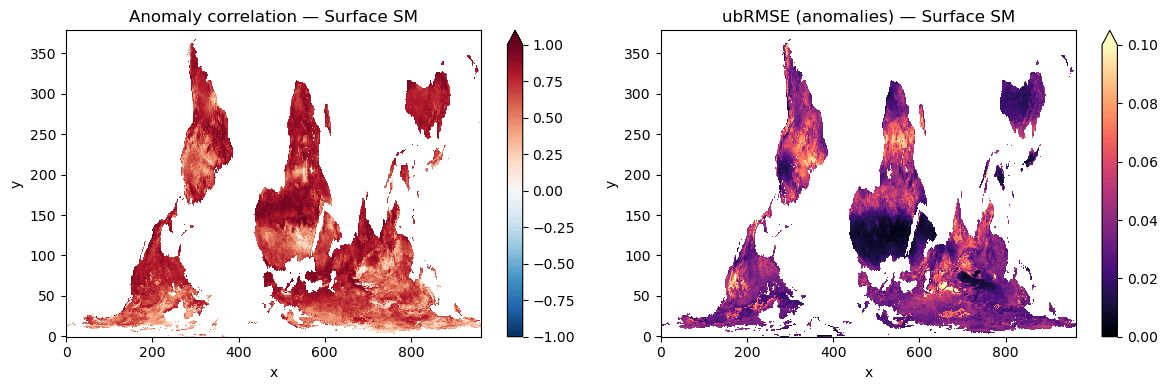

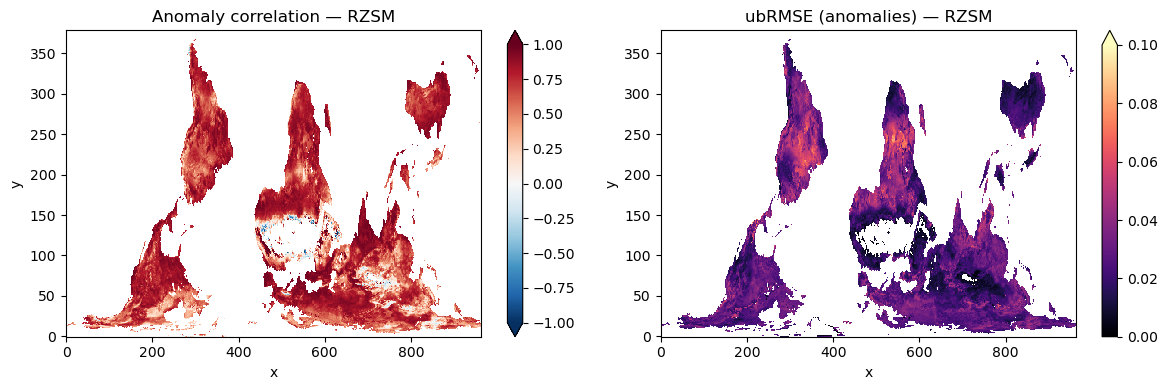

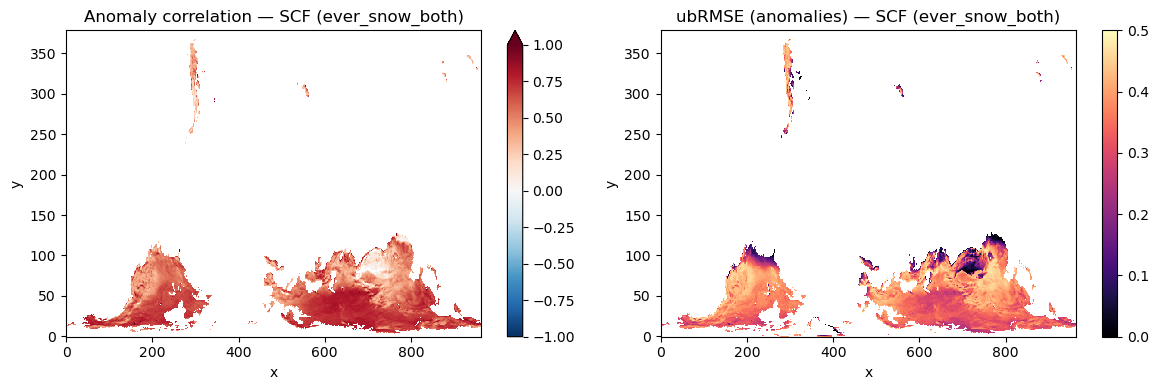

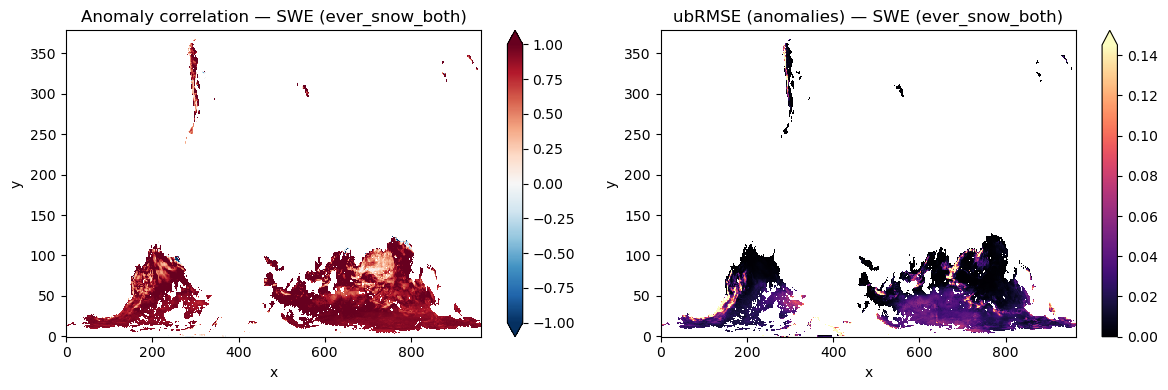

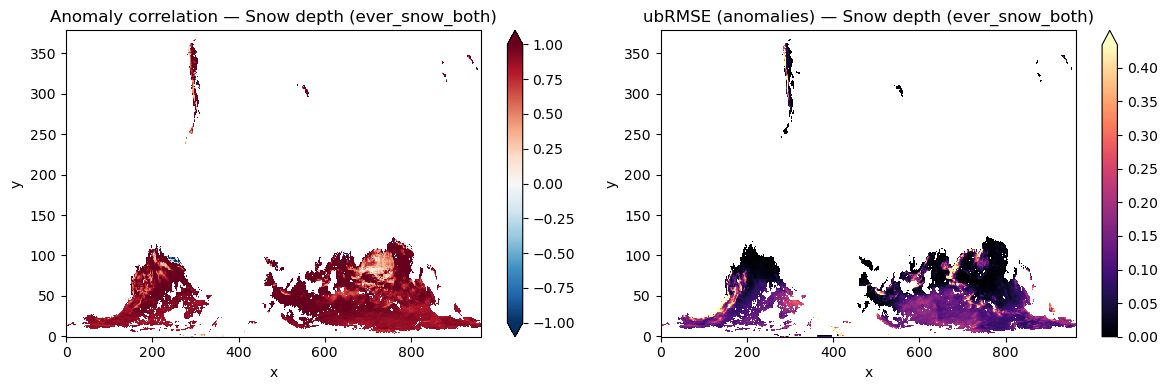

In [10]:
def _plot_pair(anom_da, ub_da, title, ub_vmax=None, ub_cmap='magma'):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    anom_da.plot(ax=ax[0], vmin=-1, vmax=1, cmap='RdBu_r')
    ax[0].set_title(f"Anomaly correlation — {title}")

    if ub_vmax is None:
        vals = np.asarray(ub_da)
        vals = vals[np.isfinite(vals)]
        ub_vmax = float(np.nanpercentile(vals, 98)) if vals.size else 1.0
        if (not np.isfinite(ub_vmax)) or (ub_vmax <= 0):
            ub_vmax = 1.0

    ub_da.plot(ax=ax[1], vmin=0, vmax=ub_vmax, cmap=ub_cmap)
    ax[1].set_title(f"ubRMSE (anomalies) — {title}")
    plt.tight_layout()
    plt.show()

_plot_pair(anomR_sfc, ubRMSE_sfc, "Surface SM", ub_vmax=0.1)
if anomR_rz is not None:
    _plot_pair(anomR_rz, ubRMSE_rz, "RZSM", ub_vmax=0.1)

_plot_pair(anomR_scf,  ubRMSE_scf,  "SCF (ever_snow_both)", ub_vmax=0.5)
_plot_pair(anomR_swe,  ubRMSE_swe,  "SWE (ever_snow_both)")
_plot_pair(anomR_snwd, ubRMSE_snwd, "Snow depth (ever_snow_both)")


In [11]:
# ensure coords are attached + CF attrs
lat2d = m36_grid["lat"].assign_attrs(standard_name="latitude", units="degrees_north")
lon2d = m36_grid["lon"].assign_attrs(standard_name="longitude", units="degrees_east")

# build dataset (2D diagnostics)
ds_out = xr.Dataset(
    data_vars={
        "R_sfc":  (("y","x"), R_sfc.values,
                        {"long_name": "Correlation (surface SM: model vs ERA5-Land swvl1)", "units": "1"}),
        "anomR_sfc":  (("y","x"), anomR_sfc.values,
                        {"long_name": "Anomaly correlation (surface SM: model vs ERA5-Land swvl1)", "units": "1"}),
        "ubRMSE_sfc": (("y","x"), ubRMSE_sfc.values,
                        {"long_name": "Unbiased RMSE of anomalies (surface SM)", "units": "m3 m-3"}),
        "rmse_sfc": (("y","x"), rmse_sfc.values,
                        {"long_name": "RMSE (surface SM)", "units": "m3 m-3"}),
        "bias_sfc": (("y","x"), bias_sfc.values,
                        {"long_name": "Bias (surface SM: model - ERA5-Land)", "units": "m3 m-3"}),

        "R_scf":  (("y","x"), R_scf.values,
                        {"long_name": "Correlation (SCF, ever_snow_both)", "units": "1"}),
        "anomR_scf":  (("y","x"), anomR_scf.values,
                        {"long_name": "Anomaly correlation (SCF, ever_snow_both)", "units": "1"}),
        "ubRMSE_scf": (("y","x"), ubRMSE_scf.values,
                        {"long_name": "Unbiased RMSE of anomalies (SCF, ever_snow_both)", "units": "1"}),
        "rmse_scf": (("y","x"), rmse_scf.values,
                        {"long_name": "RMSE (SCF, ever_snow_both)", "units": "1"}),
        "bias_scf": (("y","x"), bias_scf.values,
                        {"long_name": "Bias (SCF: model - ERA5-Land, ever_snow_both)", "units": "1"}),

        "R_swe":  (("y","x"), R_swe.values,
                        {"long_name": "Correlation (SWE, ever_snow_both)", "units": "1"}),
        "anomR_swe":  (("y","x"), anomR_swe.values,
                        {"long_name": "Anomaly correlation (SWE, ever_snow_both)", "units": "1"}),
        "ubRMSE_swe": (("y","x"), ubRMSE_swe.values,
                        {"long_name": "Unbiased RMSE of anomalies (SWE, ever_snow_both)", "units": "m"}),
        "rmse_swe": (("y","x"), rmse_swe.values,
                        {"long_name": "RMSE (SWE, ever_snow_both)", "units": "m"}),
        "bias_swe": (("y","x"), bias_swe.values,
                        {"long_name": "Bias (SWE: model - ERA5-Land, ever_snow_both)", "units": "m"}),

        "R_snwd":  (("y","x"), R_snwd.values,
                         {"long_name": "Correlation (snow depth, ever_snow_both)", "units": "1"}),
        "anomR_snwd":  (("y","x"), anomR_snwd.values,
                         {"long_name": "Anomaly correlation (snow depth, ever_snow_both)", "units": "1"}),
        "ubRMSE_snwd": (("y","x"), ubRMSE_snwd.values,
                         {"long_name": "Unbiased RMSE of anomalies (snow depth, ever_snow_both)", "units": "m"}),
        "rmse_snwd": (("y","x"), rmse_snwd.values,
                         {"long_name": "RMSE (snow depth, ever_snow_both)", "units": "m"}),
        "bias_snwd": (("y","x"), bias_snwd.values,
                         {"long_name": "Bias (snow depth: model - ERA5-Land, ever_snow_both)", "units": "m"}),

        "ever_snow_both": (("y","x"), ever_snow_both.values.astype(bool),
                            {"long_name": "Snow-domain eligibility: snow occurs at least once in both model and ERA5-Land", "units": "1"}),
    },
    coords={
        "lat": (("y","x"), lat2d.values, lat2d.attrs),
        "lon": (("y","x"), lon2d.values, lon2d.attrs),
    },
    attrs={
        "title": "ERA5-Land vs Model snow/soil diagnostics on EASEv2 M36",
        "source": "GEOS-LDAS monthly SFMC/RZMC/SNOMASLAND/SNODPLAND/FRLANDSNO; ERA5-Land swvl1-3/sd/sde/snowc regridded with xESMF",
        "history": f"created {dt.datetime.utcnow():%Y-%m-%dT%H:%MZ}",
        "Conventions": "CF-1.8",
        "grid": "EASEv2 M36 (exact, from tilecoord bounds)",
        "notes": "SCF/SWE/snow-depth metrics use ever_snow_both domain mask; includes R, anomR, ubRMSE, RMSE, and bias.",
    },
)

# add RZ maps if computed
if (('R_rz' in locals()) and (R_rz is not None)) and (('anomR_rz' in locals()) and (anomR_rz is not None)) and (('ubRMSE_rz' in locals()) and (ubRMSE_rz is not None)):
    ds_out["R_rz"]  = (("y","x"), R_rz.values)
    ds_out["R_rz"].attrs.update(long_name="Correlation (root-zone SM: model RZMC vs ERA5-Land RZ)", units="1")
    ds_out["anomR_rz"]  = (("y","x"), anomR_rz.values)
    ds_out["anomR_rz"].attrs.update(long_name="Anomaly correlation (root-zone SM: model RZMC vs ERA5-Land RZ)", units="1")
    ds_out["ubRMSE_rz"] = (("y","x"), ubRMSE_rz.values)
    ds_out["ubRMSE_rz"].attrs.update(long_name="Unbiased RMSE of anomalies (root-zone SM)", units="m3 m-3")
    ds_out["rmse_rz"] = (("y","x"), rmse_rz.values)
    ds_out["rmse_rz"].attrs.update(long_name="RMSE (root-zone SM)", units="m3 m-3")
    ds_out["bias_rz"] = (("y","x"), bias_rz.values)
    ds_out["bias_rz"].attrs.update(long_name="Bias (root-zone SM: model - ERA5-Land)", units="m3 m-3")

import gc
import matplotlib.pyplot as plt

# Free large intermediates before netCDF write to reduce peak memory pressure.
for _v in [
    "sfmc_aln", "scf_aln", "swe_model_aln", "snwd_model_aln", "rzmc_aln",
    "era_sfc_aln", "era_l2_aln", "era_l3_aln", "era_swe_aln", "era_snwd_aln",
    "era_scf_aln", "era_stl1_aln", "era_rz_aln", "ds_era", "regridder", "r",
]:
    if _v in globals():
        del globals()[_v]
plt.close("all")
_ = gc.collect()

# compression
comp = dict(zlib=True, complevel=4)
enc  = {v: {**comp, "dtype":"float32", "_FillValue": np.float32(np.nan)} for v in ds_out.data_vars if str(ds_out[v].dtype) != "bool"}
for v in ds_out.data_vars:
    if str(ds_out[v].dtype) == "bool":
        enc[v] = {**comp, "dtype":"int8", "_FillValue": np.int8(0)}
enc.update({"lat": {"dtype":"float32", **comp}, "lon": {"dtype":"float32", **comp}})

ds_out.to_netcdf(out_nc, format="NETCDF4", encoding=enc)
print(f"Wrote {out_nc}")


Wrote ERA5L_vs_OLv8_M36_masked_summary.nc


### Disabled helper cell

This previously inserted helper block is not part of the main workflow for this notebook and referenced undefined objects (`mod`/`model`). It has been disabled to prevent runtime failure.
